In [3]:
import pandas
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.impute import SimpleImputer
from matplotlib.colors import LogNorm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_curve, auc, precision_score, recall_score, f1_score, precision_recall_fscore_support, ConfusionMatrixDisplay

In [4]:
# Importing all cleaned datasets
df_usagers = pandas.read_csv("df_usagers_clean.csv")
df_caract = pandas.read_csv("df_caract_clean.csv")
df_lieux = pandas.read_csv("df_lieux_clean.csv")
df_vehicules = pandas.read_csv("df_vehicules_clean.csv")

In [5]:
df_main = df_usagers.merge(df_vehicules, on = ['Num_Acc', 'id_vehicule'], how='left')
df_main = df_main.merge(df_caract, on = ['Num_Acc'], how = 'left')
df_main = df_main.merge(df_lieux, on = ['Num_Acc'], how = 'left')

In [6]:
df_main.dropna(inplace = True)

In [7]:
df_main.to_csv("df_clean.csv", index=False)

In [8]:
features_usagers = ['place', 'catu', 'sexe', 'age', 
       'aucun', 'ceinture', 'casque', 'dispositif_enfant', "trajet",
       'gilet_reflechissant', 'airbag', 'gants',"non determinable", 'autre']


binary_features_usagers = ['aucun', 'ceinture', 'casque', 'dispositif_enfant', 'gilet_reflechissant', 'airbag', 'gants', "non determinable", 'autre']
numerical_features_usagers = ["age"]
categorical_features_usagers = list(set(features_usagers) - set(binary_features_usagers) - set(numerical_features_usagers))


In [9]:
categorical_features_lieux = ['catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf','infra', 'situ']
numerical_features_lieux = ["vma"]

features_lieux = categorical_features_lieux + numerical_features_lieux

In [10]:
categorical_features_vehicules = ['catv', 'obs', 'obsm', 'choc', 'manv', 'motor',"senc"]
numerical_features_vehicules = []
features_vehicules = categorical_features_vehicules + numerical_features_vehicules

In [11]:
categorical_features_caract = [
 'lum',
 'agg',
 'int',
 'atm',
 'col'
]
binary_features_caract = ["is_weekend"]     
numerical_features_caract = ['lat', 'long', 'day_sin',
       'day_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos',
       'hour_sin', 'hour_cos'] # binary numerical features is_weekend

features_caract = categorical_features_caract + binary_features_caract + numerical_features_caract

In [12]:
num_features = numerical_features_usagers + numerical_features_caract
cat_features = categorical_features_usagers + categorical_features_caract + categorical_features_lieux + categorical_features_vehicules
bin_features = binary_features_usagers + binary_features_caract

features = num_features + cat_features + bin_features
target = "grav_bin"

In [21]:
['grav_bin'] in features

False

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

preprocessor_cat_only = ColumnTransformer(
    transformers=[
        ("cat", "passthrough", cat_features)
    ],
    remainder="drop"
)

In [14]:
X = df_main[features]
y = df_main[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("bin", "passthrough", bin_features)
    ]
)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

for name, pipe in pipelines.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=5) # un label prédit pour chaque exemple de X_train
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_train, y_pred))


 Logistic Regression
Precision: 0.6367401469605879
Recall: 0.3492854525467204
F1: 0.45111216280170374
Accuracy: 0.740902084310703
              precision    recall  f1-score   support

           0       0.76      0.91      0.83     31118
           1       0.64      0.35      0.45     13645

    accuracy                           0.74     44763
   macro avg       0.70      0.63      0.64     44763
weighted avg       0.72      0.74      0.71     44763


 Decision Tree
Precision: 0.49985549132947976
Recall: 0.5069989006962258
F1: 0.5034018555575769
Accuracy: 0.6950829926501798
              precision    recall  f1-score   support

           0       0.78      0.78      0.78     31118
           1       0.50      0.51      0.50     13645

    accuracy                           0.70     44763
   macro avg       0.64      0.64      0.64     44763
weighted avg       0.70      0.70      0.70     44763


 Gradient Boosting
Precision: 0.66350531107739
Recall: 0.38453646024184684
F1: 0.4868927

In [22]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = .2)
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val) # un label prédit pour chaque exemple de X_train
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average="binary")
    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)
    
    print(classification_report(y_val, y_pred))


 Logistic Regression
Precision: 0.6528460997891778
Recall: 0.3440740740740741
F1: 0.4506427358719379
Accuracy: 0.7529432790474275
              precision    recall  f1-score   support

           0       0.76      0.92      0.84      6253
           1       0.65      0.34      0.45      2700

    accuracy                           0.75      8953
   macro avg       0.71      0.63      0.64      8953
weighted avg       0.73      0.75      0.72      8953


 Decision Tree
Precision: 0.9996290801186943
Recall: 0.9981481481481481
F1: 0.9988880652335063
Accuracy: 0.7529432790474275
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6253
           1       1.00      1.00      1.00      2700

    accuracy                           1.00      8953
   macro avg       1.00      1.00      1.00      8953
weighted avg       1.00      1.00      1.00      8953


 Gradient Boosting
Precision: 0.6850291639662994
Recall: 0.3914814814814815
F1: 0.4982323

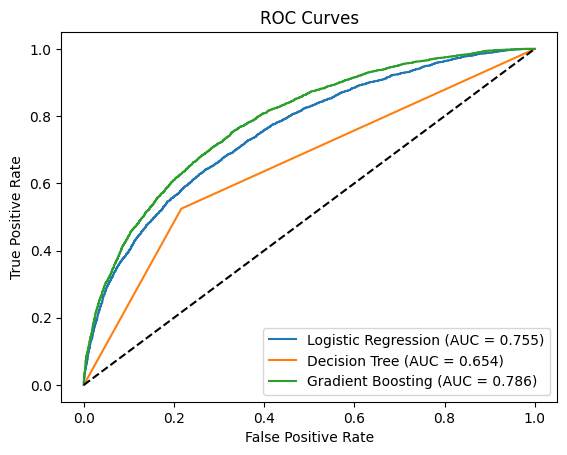

In [17]:
plt.figure()

for name, pipe in pipelines.items():

    y_proba = pipe.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

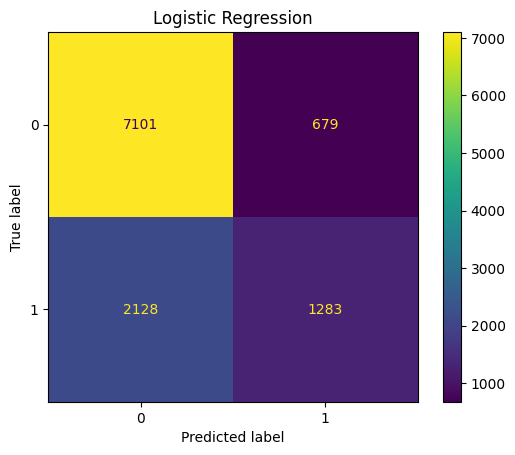

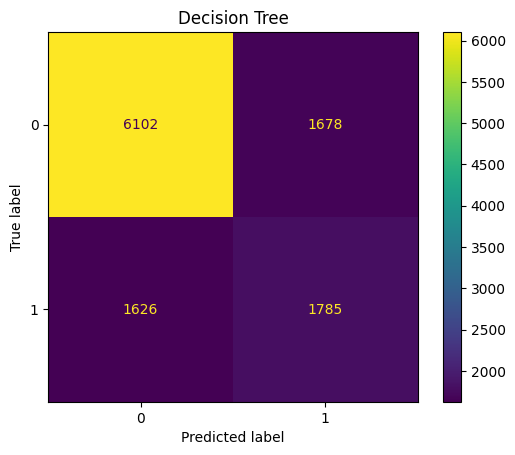

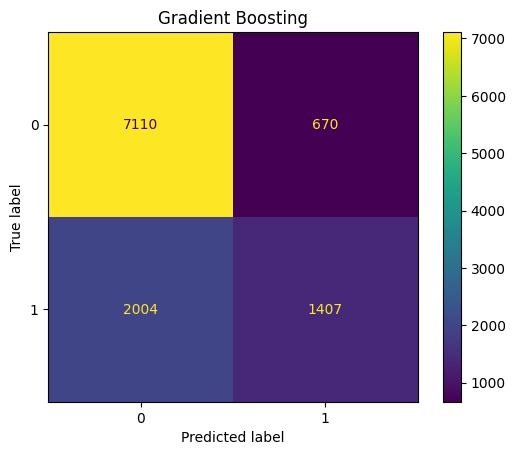

In [18]:
for name, model in pipelines.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name)
    plt.show()